In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

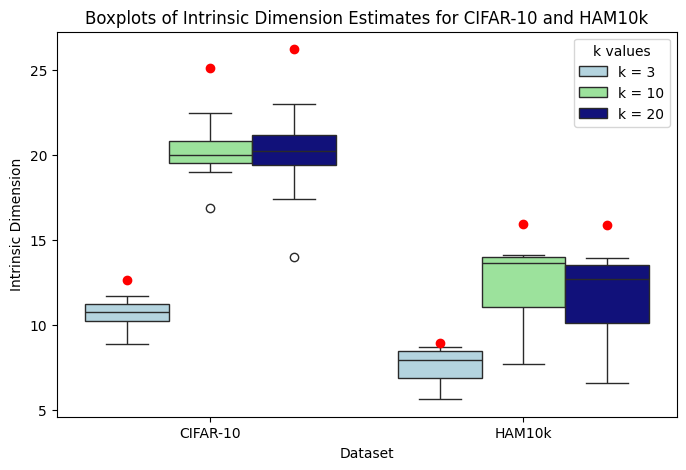

In [2]:
# Define k values
ks = [3, 10, 20]  

# Dummy intrinsic dimension data (replace with actual computed values)
cifar10_dims = {3: [8.87, 10.12, 11, 10.71, 10.38, 11.4, 10.03, 11.29, 10.76, 11.71], 
                10: [16.84, 19.44, 20.06, 19.76, 19.87, 20.84, 20.87, 20.80, 18.95, 22.43],
                20: [17.37, 20.09, 20.22, 19.97, 20.30, 20.95, 21.75, 21.38, 18.76, 23,14]}

ham10k_dims = {3: [8.70, 8.48, 8.39, 5.88, 7.81, 7.91, 5.61],
                10: [13.63, 13.55, 14.07, 8.5, 13.93, 14.03, 7.66],
                20: [12.7, 12.53, 13.57, 7.61, 13.42, 13.94, 6.59]}

# Full dataset estimates (replace with actual values)
cifar10_full = {3: [12.63], 10: [25.07], 20: [26.2]}
ham10k_full = {3: [8.92], 10: [15.89], 20: [15.86]}

# Create a DataFrame
df_list = []
for k in ks:
    df_list.append(pd.DataFrame({
        "Intrinsic Dimension": np.concatenate([cifar10_dims[k], ham10k_dims[k]]),
        "Dataset": ["CIFAR-10"] * len(cifar10_dims[k]) + ["HAM10k"] * len(ham10k_dims[k]),
        "k": [f"k = {k}"] * (len(cifar10_dims[k]) + len(ham10k_dims[k]))
    }))
df = pd.concat(df_list)

# Create the box plot
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x="Dataset", y="Intrinsic Dimension", hue="k", data=df, palette=["lightblue", "lightgreen", "darkblue"])

# Get base x-tick positions (centers of CIFAR-10 and HAM10k)
x_ticks = np.array(ax.get_xticks())  

# Compute offsets for each k using Seaborn's internal spacing
num_k = len(ks)
box_group_width = 0.8  # Total width of grouped boxes (Seaborn default)
spacing = np.linspace(-box_group_width / 3, box_group_width / 3, num_k)  # Compute exact offsets

# Plot the red dots at the correct locations
for i, k in enumerate(ks):
    plt.scatter(
        x_ticks + spacing[i],  # Shift red dots precisely to center of each k box
        [cifar10_full[k], ham10k_full[k]],  
        color="red",
        zorder=3,
        label=None
    )

# Labels and legend
plt.ylabel("Intrinsic Dimension")
plt.legend(title="k values")
plt.title("Boxplots of Intrinsic Dimension Estimates for CIFAR-10 and HAM10k")

plt.show()
